In [2]:
import sys
import os

# Adds the project root directory to the Python search path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.train_test_split import time_split
from models.arima_model import train_arima
from models.lstm_model import create_sequences, build_lstm, scale_data
from models.evaluation import mae, rmse

I0000 00:00:1783102781.582903   60091 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783102781.748804   60091 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783102784.268168   60091 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
df = pd.read_csv("../data/raw/TSLA.csv", parse_dates=["Date"])
df = df.set_index("Date")

df = df.asfreq("B")
df = df.ffill()

df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000.0
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500.0
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500.0
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000.0
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500.0


In [4]:
train, test = time_split(df["Close"])

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 2608
Test size: 392


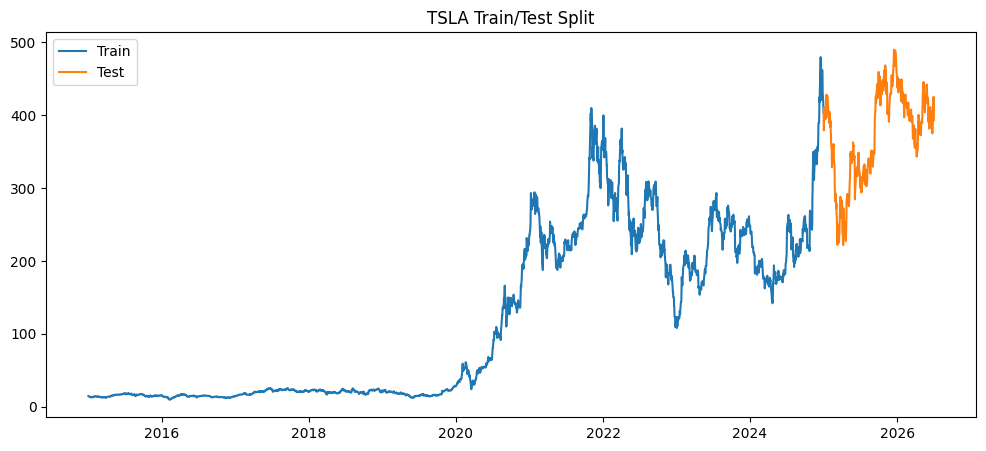

In [5]:
plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title("TSLA Train/Test Split")
plt.legend()
plt.show()

In [6]:
print("Training ARIMA...")

arima_model = train_arima(train, order=(5,1,0))

arima_forecast = arima_model.forecast(steps=len(test))
arima_forecast = pd.Series(arima_forecast, index=test.index)

Training ARIMA...


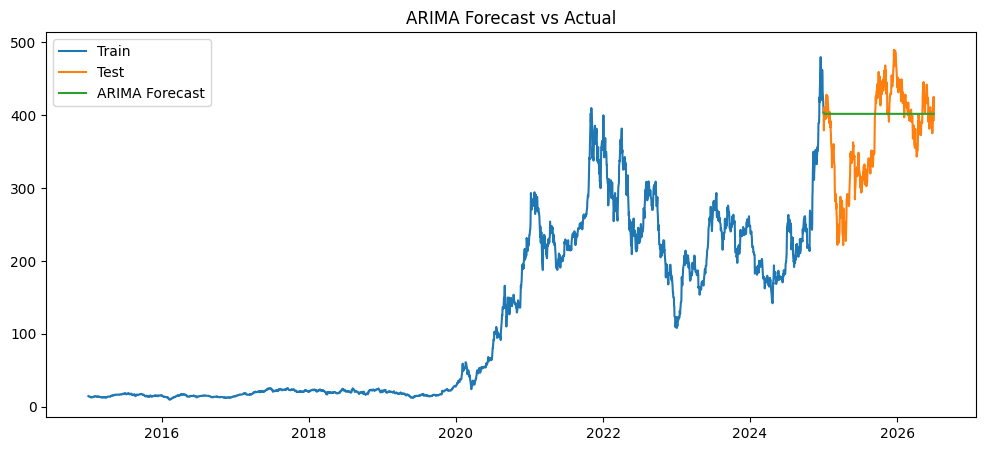

In [7]:
plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(arima_forecast, label="ARIMA Forecast")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

In [8]:
print("Preparing LSTM data...")

data = df["Close"].values
scaled, scaler = scale_data(data)

X, y = create_sequences(scaled, window=60)

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = build_lstm(60)

model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

Preparing LSTM data...


E0000 00:00:1783102786.510933   60091 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/welela/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.0083
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 9.8307e-04
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 8.6030e-04
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 7.1485e-04
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 6.6581e-04
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 5.7759e-04
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 4.8174e-04
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 4.8467e-04
Epoch 9/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 4.0841e-04
Epoch 10/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 3.6998e-04


In [9]:
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


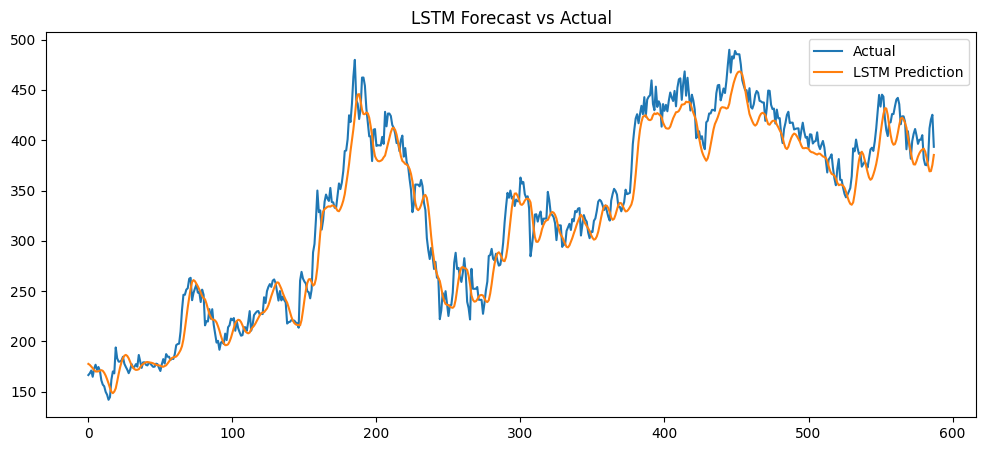

In [10]:
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label="Actual")
plt.plot(pred, label="LSTM Prediction")
plt.title("LSTM Forecast vs Actual")
plt.legend()
plt.show()

In [11]:
print("ARIMA Results")
arima_mae = mae(test.values, arima_forecast.values)
arima_rmse = rmse(test.values, arima_forecast.values)

print("MAE:", arima_mae)
print("RMSE:", arima_rmse)

print("\nLSTM Results")
lstm_mae = mae(y_test_inv, pred)
lstm_rmse = rmse(y_test_inv, pred)

print("MAE:", lstm_mae)
print("RMSE:", lstm_rmse)

ARIMA Results
MAE: 53.50007479530659
RMSE: 69.14463767244608

LSTM Results
MAE: 15.409756121992258
RMSE: 20.089505068956267


In [12]:
results = pd.DataFrame({
    "Model": ["ARIMA", "LSTM"],
    "MAE": [arima_mae, lstm_mae],
    "RMSE": [arima_rmse, lstm_rmse]
})

results

,Model,MAE,RMSE
0,ARIMA,53.500075,69.144638
1,LSTM,15.409756,20.089505


## Conclusion

- ARIMA performs reasonably but struggles with nonlinear stock behavior.
- LSTM captures complex patterns better and achieves lower error.
- LSTM is more suitable for volatile assets like TSLA.